# Assignment of DSAIT4310 

September 13, 2026

Consider the processed ”SFHH” face-to-face contact network at a conference, which is given in the following format: each row ”$a\ b\ t$” denotes an undirected contact (a temporal link) between node $a$ and $b$ at time step $t$. This contact network is sampled/measured once every 20 seconds during a conference. Thus, each time step has a duration of 20s, which is though not relevant for our analysis in this assignment. We denote this temporal network as $G_{data}$.

**A.** 
Explore properties of network $G$ that is aggregated over all the $T = 3259$ steps. Specifically, the aggregated network $G$ is composed of all the nodes that have ever appeared in the dataset and any two nodes are connected by a link if they have at least a contact over the whole period $[1, T ]$.
Compute the following topological properties of $G$ in 1)-6) without considering the weight of any link and the link weight property in 7).

## Imports

In [1]:
from scipy.stats import binom

1) What is the number of nodes $N$, the link density $p$ and standard deviation of the degree $\sqrt{Var[D]}$?

In [76]:
import pandas as pd
import numpy as np
import networkx as nx

df = pd.read_excel("G_data.xlsx")

G = nx.from_pandas_edgelist(df, source="node1", target="node2")

N = G.number_of_nodes()

E = G.number_of_edges()

p = nx.density(G)

degrees = np.array([d for node, d in G.degree()])

std_d = np.std(degrees)

print(f"Number of Nodes N: {N}")
print(f"Number of Edges E: {E}")
print(f"Link desnity p: {p}")
print(f"Standard Deviation of the degree: {std_d}")

Number of Nodes N: 403
Number of Edges E: 9510
Link desnity p: 0.11740305914595756
Standard Deviation of the degree: 29.945173790927317


2) Plot the degree distribution. Which network model, Erdős-Rényi (ER) random graphs or scale-free networks, could better model this network with respect to degree distribution? Explain how you arrived at your conclusion.

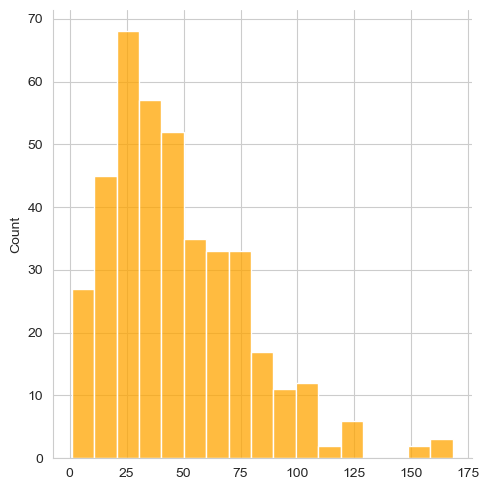

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.displot(degrees, color='orange')

>ER random graphs are characterized by a binomial or poisson like degree distribution. They have a tightly clustered degree distribution around a mean degree and bell curve shape.
>Contrasting, scale free networks or Power-law networks are characterized by a large number of nodes with few links and a long and pronounced tail of few nodes with a very high amount of links.
> In conclusion, id argue that the plotted distribution resembles a ER random graph. It's hard to draw any hard conclusion, but I think we can see a clear bell curve shape clustered around the mean value. Notebly we see the distribution clustering on the left side (so many nodes with compartively fewer links), but i would argue the tail is not as pronounced as one might expect from a scale free network. 

### Expected ER vs actual data

For an Erdős–Rényi graph $G(N,p)$, each node has $N-1$ possible neighbours, and each link exists independently with probability $p$. A node’s degree therefore follows:</br>
$ D_{\mathrm{ER}}\sim\operatorname{Binomial}(N-1,p), \qquad \operatorname{Var}(D_{\mathrm{ER}})=(N-1)p(1-p). $ 

Using the network’s $N=403$ and $p=0.117403$, we would expect:</br>
$\sigma_{\mathrm{ER}} =\sqrt{402(0.117403)(1-0.117403)} \approx 6.45.$

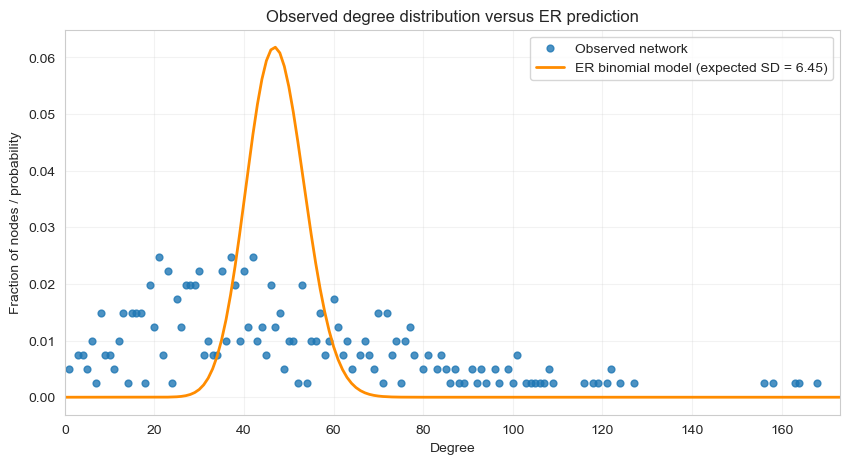

Observed degree SD: 29.95
ER expected degree SD: 6.45


In [4]:
# G and degrees were created in question 1.
N = G.number_of_nodes()
p = nx.density(G)
degrees = np.array([degree for _, degree in G.degree()])

# Observed probability mass: fraction of nodes with each degree.
degree_values, counts = np.unique(degrees, return_counts=True)
observed_pmf = counts / N

# ER prediction for a graph with the same N and link probability p.
k = np.arange(N)
er_pmf = binom.pmf(k, N - 1, p)
er_std = np.sqrt((N - 1) * p * (1 - p))

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    degree_values, observed_pmf,
    s=24, alpha=0.8, label="Observed network"
)
ax.plot(
    k, er_pmf,
    color="darkorange", linewidth=2,
    label=f"ER binomial model (expected SD = {er_std:.2f})"
)

ax.set(
    xlabel="Degree",
    ylabel="Fraction of nodes / probability",
    title="Observed degree distribution versus ER prediction",
    xlim=(0, max(degrees) + 5),
)
ax.legend()
ax.grid(alpha=0.25)
plt.show()

print(f"Observed degree SD: {np.std(degrees):.2f}")
print(f"ER expected degree SD: {er_std:.2f}")

### Suggested alternative for Q2 answer

The degree distribution is much broader than expected for an ER graph with the same number of nodes and link density. Its mean degree is about 47.2 and its standard deviation is about 29.9, compared with an expected ER standard deviation of about 6.45. Thus, of the two proposed models, a long-tailed or scale-free model is qualitatively closer with respect to degree spread. A histogram alone does not demonstrate that the degrees follow a power law.

3) What is the degree correlation (assortativity) $\rho_D$? What is its physical meaning?

In [4]:
a = nx.degree_assortativity_coefficient(G)

print(f"Degree corelation: {a}")

Degree corelation: -0.08001195267658665


>The physical meaning of the degree correlation is the likelihood or preference of nodes to attach to nodes that are similiar in some specific meassure. The Degree corelation can range between -1 and 1. So in this case we see a very slight negative corelation, which implies there is no preference for similiar nodes to connect.

4) What is the clustering coefficient $C$?

In [5]:
C = nx.average_clustering(G)

print(f"Clustering coefficient C: {C}")

Clustering coefficient C: 0.2775234288603668


5) What is the average hopcount $E[H]$ of the shortest paths between all node pairs? What is the diameter $H_max$?

In [6]:
avg_hopcount = nx.average_shortest_path_length(G)

H_max = nx.diameter(G)

print(f"Average hopcount C: {avg_hopcount}")
print(f"Diameter: {H_max}")

Average hopcount C: 1.955211535375233
Diameter: 4


6) Has this network the small-world property? Justify your conclusion quantitatively (Hint: Lecture 2).

> According to the lecture, small-world property is a well define term. A graph has a small-world property, if it has a high clustering coefficient and low distances. More concretly it is usualy quantified by the 'small-coefficient' $\sigma = \cfrac{\cfrac{C}{C_r}}{\cfrac{L}{L_r}}$ if $\sigma \gt 1 (C\gg C_r\ and\ L \approx L_r)$ in comparison to a Erdős–Rényi model with same degree on average. The easiest way to quantify this is to generate a Erdős–Rényi random graph with a similar degree and compare our two graphs.

In [7]:
ERG = nx.erdos_renyi_graph(N,E, 1110)
C_ERG = nx.average_clustering(ERG)
L_ERG = nx.average_shortest_path_length(ERG)


sigma = (C / C_ERG) / (avg_hopcount / L_ERG)

print(f"Small-world coefficient sigma: {sigma}")

print(f"Clustering: {C}")
print(f"Path length: {avg_hopcount}")
print(f"Clustering ER: {C_ERG}")
print(f"Path length ER: {L_ERG}")

Small-world coefficient sigma: 0.14194035982255296
Clustering: 0.2775234288603668
Path length: 1.955211535375233
Clustering ER: 1.0
Path length ER: 1.0


> We can see the small world property is not fullfield according to the small-world coefficient, thus this graph does not have small-world property

### Error in Q6

In [11]:
ERG = nx.erdos_renyi_graph(N,p, 1110)
C_ERG = nx.average_clustering(ERG)
L_ERG = nx.average_shortest_path_length(ERG)


sigma = (C / C_ERG) / (avg_hopcount / L_ERG)

print(f"Small-world coefficient sigma: {sigma}")

print(f"Clustering: {C}")
print(f"Path length: {avg_hopcount}")
print(f"Clustering ER: {C_ERG}")
print(f"Path length ER: {L_ERG}")

Small-world coefficient sigma: 2.238929736612905
Clustering: 0.2775234288603668
Path length: 1.955211535375233
Clustering ER: 0.1195426301118
Path length ER: 1.885633865412392


The code above is almost the same as the original code with the only change being in the `nx.erdos_renyi_graph()`. Where originally `E`, was used there is now the link density `p` used. The function takes as a second argument for contructing an ER-type graphs the link probability but we used the total number of links. This sets it to 1 as probabilities don't go above 1, but results in an incorrect comparison. When using the link density we get very different numbers and the small-world propertty does seem to be supported

### Suggested alternative for Q6 

At this density, an ER graph is expected to have clustering close to $p=0.1174$, compared with the observed $C=0.2775$: about $2.36$ times higher than the expected ER-value. Its typical path length is about $1.88$, compared with the observed $1.96$: only about $4\%$ longer. These give $\sigma$ of roughly $2.23$, supporting the conclusion that the aggregated network has a small-world property under the criterion stated earlier in the notebook. A single generated ER graph will give slightly different reference values, so the actual $\sigma$ need not equal $2.23$ exactly.

7) Consider further the weight of each link in $G$, which is the total number of contacts between the corresponding two nodes within $[1, T ]$. Plot the probability density function (distribution) of the link weight (Choose the scales of the two axes and the bins/bin-size for the distribution such that the plot is insightful for interpretation).
The probability density function $f_W(x)$ of the weight $W$ of a link is defined as $f_W(x) = \lim_{\Delta x \to 0} \frac{Pr[x < W \le x + \Delta x]}{\Delta x}$,
the probability that the variable (or the percentage of links whose weight) is within each range or bin $(x, x+\Delta x]$ normalized by the size of the bin $\delta x$. Does $W$ follow a power-law distribution? Explain how you arrived atyour conclusion. Hint: All metrics computed for the network $G$ are recommended to put into a table.

Text(0, 0.5, 'f_W(x)')

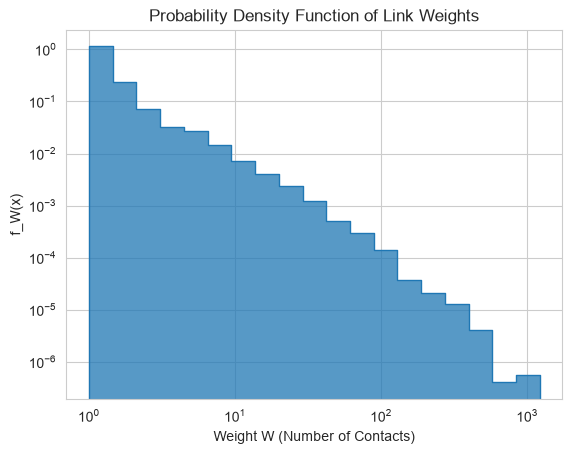

In [ ]:
from IPython.display import display

df["node_min"] = df[["node1", "node2"]].min(axis=1)
df["node_max"] = df[["node1", "node2"]].max(axis=1)

df_weights = df.groupby(["node_min", "node_max"]).size().reset_index(name="weight")

weights = df_weights['weight'].values

bins = np.logspace(np.log10(min(weights)), np.log10(max(weights)), num=20)

sns.histplot(weights, bins=bins, stat="density", element="step")
plt.xscale('log')
plt.yscale('log')





**B.**
We consider the following information spreading process, which is actually a simplified Susceptible-Infected
model but on a temporal network. Initially, at time $t = 0$, a single node $s$ is infected meaning that this
node possesses the information whereas all the other nodes are Susceptible, thus have not yet perceived the
information. Node $s$ is also called the seed of the information. Whenever an infected node $i$ is in contact with
a susceptible node $j$ at any time step $t$, the susceptible node becomes infected during the same time step and
could possibly infect other nodes only since the next time step via its contacts with susceptible nodes. Once a
node becomes infected, it stays infected forever. For example, assume that the seed node $s$ has its first contact
at time $t = 5$ and that contact is with node $m$. Although node $s$ gets infected since $t = 0$, it infects a second
node, i.e. node $m$ only at $t = 5$ when it contacts $m$. Infection happens only when an infected node and a
susceptible node are in contact. The number of infected nodes is non-decreasing over time.
Simulate the information spreading process on the given temporal network $G_data$ for $N$ iterations. Each
iteration starts with a different seed node infected at $t = 0$ and ends at $t = T = 3259$ the last time step that
the network is measured. Via the $N$ iterations, we consider the spreading process that starts at every node
$i \in [1, N ]$. Record the total number of infected nodes $I(t)$ at each step $t$ for each iteration.

In [91]:
nodes = pd.concat([df["node1"], df["node2"]]).unique()

number_nodes = len(nodes)

node_to_index = {node: i for i, node in enumerate(nodes)}   # Mapping of Node to index

df_sorted = df.sort_values(by="timestamp")  # Sort so we are sure timesteps are in order

node1_arr = df_sorted["node1"].map(node_to_index).values    # translate node number to index
node2_arr = df_sorted["node2"].map(node_to_index).values   
time_arr = df_sorted["timestamp"].values

timesteps, t_indices = np.unique(time_arr, return_index=True)   #so we have index for every time step

t_indices = np.append(t_indices, len(time_arr)) # prevents out of bounds in our slicing for the last element


I_state = np.eye(number_nodes, dtype=bool)      # Identity matrix with bool for initial condition
infection_counts = np.zeros((len(timesteps),number_nodes), dtype=int)

for i in range(len(timesteps)):
    start_index, end_index = t_indices[i], t_indices[i+1]       # get range of all meetings at that timestep

    node1_t, node2_t = node1_arr[start_index: end_index], node2_arr[start_index: end_index]

    state_n1_to_n2 = I_state[node1_t, :].copy()     # get status of all people in node1
    state_n2_to_n1 = I_state[node2_t, :].copy()     # get status of all people in node2

    np.logical_or.at(I_state, node2_t, state_n1_to_n2)
    np.logical_or.at(I_state, node1_t, state_n2_to_n1)

    infection_counts[i, :] = I_state.sum(axis=0)    # count all 1 along row


infection_counts_df = pd.DataFrame(infection_counts, index=timesteps, columns=nodes)
infection_counts_df.index.name = "timestamp"
infection_counts_df.columns.name = "seed_node"

8) Taking all the $N$ iterations into count, plot the average number of infected nodes $E[I(t)]$ together with its error bar standard deviation $\sqrt{Var[I(t)]}$ as a function of the time step $t$.

<ErrorbarContainer object of 3 artists>

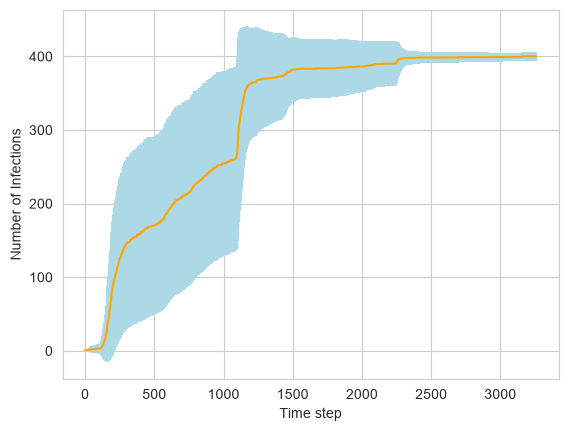

In [92]:
mean_infections = infection_counts_df.mean(axis=1)
std_infetions = infection_counts_df.std(axis=1)

plt.xlabel("Time step")
plt.ylabel("Number of Infections")
plt.errorbar(timesteps, mean_infections, yerr=std_infetions, color="orange", ecolor="lightblue")


9) How influential a node is as a seed node could be quantified by the total number of nodes that have been
infected by a specific time $t^{(l)} = 1200$ when that node is the sole seed node. This total number of infected nodes
at $t^{(l)} = 1200$ is also called the influence of that node. Plot the influence of every node in descending order.
Rank all nodes by influence and store the ranking in a vector $R = [R(1) , R(2) , ..., R(N ) ]$ where $R(i)$ represents the
index of the i-th most influential node and $R_{(1)}$ is the most influential node. (Note: you don’t need to include
this vector in your report.)

Text(0, 0.5, 'Influence (Number of infected at t=1200)')

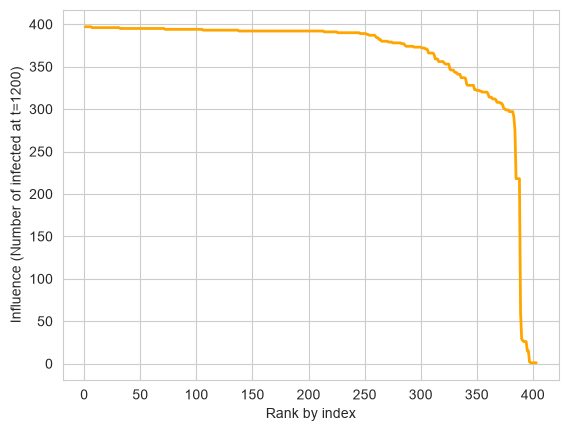

In [98]:
influence_at_1200 = infection_counts_df.loc[1200]

sorted_influences = influence_at_1200.sort_values(ascending=False)

R = sorted_influences.index.values

ranks = range(1, len(sorted_influences) + 1)

sns.lineplot(x=ranks, y=sorted_influences.values, color="orange", linewidth=2)

plt.xlabel("Rank by index")
plt.ylabel("Influence (Number of infected at t=1200)")



We will explore which nodal level network feature (centrality metric) in network $G_{data}$ better predicts nodal influence described above. First, compute the total number of unique nodes that each node $i$ has contacted during the time interval $[1, t^{(l)}]$. This is equivalent to the degree $d^{t^{(l)}}_i$ of node $i$ in the aggregated network which is formed by aggregating the temporal network $G_{data}$ over $[1, t^{(l)}]$. Based on this centrality metric derived for every node, construct the ordered vector $D = [D_{(1)} , D_{(2)}, ..., D_{(N)}]$, where $D_{(i)}$ is the node index with the $i − th$
highest degree in this aggregated network over $[1, t^{(l)}]$. How precisely a centrality metric (such as node degree in an aggregated network) predicts the ranking of nodes by influence could be quantified by the top $f$ recognition rate $r_{RD}(f) = \cfrac{|R_f \cap D_f|}{|R_f|}$ where $R_f$ and $D_f$ are the sets of nodes ranking in the top $f$ fraction according to influence and degree (in aggregated network) respectively and $|R_f| = fN$ is the number of nodes in $R_f$.

(a) Plot $r_{RD}(f)$ as a function of $f$ for $f = 0.05, 0.1, 0.15, ..., 0.5$.

Note on ties: It is possible that multiple nodes may share the same rank, the selection of $R_f$ or $D_f$ may not be unique. In such case, $r_{RD}(f)$ must be computed as the average of 1000 iterations. In each iteration, $R_f$ and $D_f$ are sampled independently and uniformly at random from their corresponding possible choices and further
used to compute the recognition rate. (This randomized tie-breaking procedure applies to all recognition rate calculations in this assignment.) Consider the degree sequence $d^{t^{(l)}}_1 = 3, d^{t^{(l)}}_2 = 1, d^{t^{(l)}}_3 = 1, {d^{t^{(l)}}_4 = 1}$ as an example. $D_{f=0.5} =0.5$ (top 2 nodes) has three possible choices ${1, 2}, {1, 3}$ and ${1, 4}$. A random choice $D_{f=0.5}$ from possible sets could also be obtained by firstly choosing the rank of nodes $2, 3$ and $$4$ by degree as a randomized/reshuffled vector of $[2, 3, 4]$ since node $1$ has rank $1$ and afterwards selecting the $2$ nodes out of the $4$ with the highest rank.

Similarly, compute the degree $d^{t^s}_i$ of each node $i$ in the aggregated network formed by aggregating $G_{data}$ over $[1, t^s]$, where $t^s = 600$. Metric $d^{t^s}_i$ could also be used to estimate the ranking of nodes by influence. Construct the corresponding ordered vector $D' = [D'_{(1)}, D'_{(2)}, ..., D'_{(N)}]$, where $D'_{(i)}$ is the node index with the $i−th$ highest degree in the aggregated network over $[1, t^{(1)}]$.

(b) Plot $r_{RD'}(f)$ as a function of $f$ for $f = 0.05, 0.1, 0.15, ..., 0.5$.

Consider a third nodal property: the time $Z_i$ when node $i$ makes its first contact in network $D_{data}$ . Construct the ordered vector $Z = [Z_{(1)}, Z_{(2)}, ..., Z_{(N)}]$, where $Z_{(i)}$ is the node index with the $i−th$ shortest time to make its first contact and use $Z$ to predict nodes’ ranking by influence.

(c) Plot the recognition rate $r_{RZ}(f)$ as a
function of $f$ for $f = 0.05, 0.1, 0.15, ..., 0.5$.

Plot the recognition rates obtained in (a), (b), and (c) on a single
figure for direct comparison.

(d) Which centrality metric $d^t_i$, $d^{t^l}_i$ or $Z_i$ best predict the ranking of nodes by influence and which performs the worst? Why?

10) The short-term influence of a node $i$ is defined as the total number of nodes that have been infected at $t^{(s)} = 600$ when node $i$ is the single seed node. Rank nodes by their short-term influence and record the ranking in a vector $R' = [R'_{(1)}, R'_{(2)}, ...,R'_{(N)}]$ where $R'_{(i)} is the index of the node with the $i − th$ highest short-term
influence. This short-term influence can also be used to estimate the influence (long-term) defined in 9). Plot the recognition rate $r_{RR'}(f)$ as a function of $f$ in the same figure as in question (9). Can this short-term influence better predict (long-term) influence in ranking than those three centrality metrics studied in 9)? Why?

11) Another temporal network $G_2$ is given the attachment and is obtained as follows. $G2$ is $G_{data} where the time stamps describing when each temporal link (contact) appears in $G_data$ are randomized. In other words, $G_2$ is constructed by copying all the temporal links ${(a, b, t)}$ from $G_{data}$ but their time stamps $t$ are randomly re-shuffled. The number of contacts between each node pair remains the same between $G_{data}$ and $G_2$. Now, perform the same analysis in 8)-10) for $G_2$ .
In this case, the spreading process unfolds on $G_2$ and all centrality metrics and nodal influences are to be derived from $G_2$.

a) Similar to question 8), plot the average number of infected nodes $E[I(t)]$ together with its error bar (standard deviation $\sqrt{Var[I(t)]}$ as a function of the time step $t$ for network $G_2$. Compare this result obtained from $G_2$ with your answer to 8) derived from $G_{data}$. What is the key difference? Please explain it.

b) Similary to 9) and 10), plot $r_{RD}(f), r_{RD'}(f), r_{RZ}(f)$ and $r_{RR'}(f)$ respectively for $G_2$ as a function of $f$.
Compare your results here obtained from $G_2$ and answers to 9) and 10) obtained from $G_{data}$. What is the key difference? Explain the key difference.

Note: Questions asking ’why’ or requesting explanations refer specifically to the causes behind your observations.